In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib import cm

import graph_state.graph_state as gs
from experiment_module.experiment_runner import bell_sampling_fidelity_experiment
from experiment_module.experiment_results_processor import load_bsqn_fidelity_estimation_data

# Further evaluation of the random sampling BSQN protocol

These experiments expand on the original paper's experiment. Our goal is to see how
the estimator's precision behaves as we vary the number of samples and of
stabilizers. In the original paper, they fix one parameter and check how the
other behaves; this method provides only a limited view of the algorithm.
Here, we will vary the two parameters to try to see a clearer picture.

## I. Generating the data

In [2]:
num_qubits = 40
repeats = 50
fidelities = [0.53]
graphs = [gs.GraphState(num_qubits, "complete")]
err_models = ["depolarizing", "single-qubit-dephasing", "bimodal"]
num_shots = np.logspace(2, 5, 50).astype(int)       # num_samples = 2 * num_shots

logstep = (np.log10(num_qubits ** 3) - np.log10(num_qubits)) / 50
num_stabilizers = list(np.round(
    [10 ** (np.log10(num_qubits) - i * logstep) for i in range(10, 0, -1)]
).astype(int).astype(str)) + list(
    np.round(
        np.logspace(np.log10(num_qubits), np.log10(num_qubits ** 3), 50)
    ).astype(int).astype(str)
)
overwrite = False

bell_sampling_fidelity_experiment(
    graphs=graphs,
    err_model=err_models,
    fidelity=fidelities,
    num_shots=num_shots,
    num_repeats=repeats,
    stabilizer_factors=num_stabilizers,
    output_dir="simulation_data/deltaf_parameter_matrix",
    overwrite=overwrite,
)

Saving experiment data to: 'simulation_data/deltaf_parameter_matrix/'
Starting Bell random sampling experiment for 1 graph(s), 3 error model(s), 1 fidelity value(s), 50 shot setting(s), and 60 stabilizer factor(s).
Total combinations (jobs) to run: 9000
Running on 14 processes...


Running Experiments: 100%|██████████| 9000/9000 [00:14<00:00, 607.20it/s]


--- Experiment Run Summary ---
Successfully saved: 0
Skipped (existed):  9000
Failed:             0


## II. Retrieving everything

In [3]:
df = load_bsqn_fidelity_estimation_data("simulation_data/deltaf_parameter_matrix")
df

,qubits,input_fidelity,error_model,shots,numstab,repeat,estimated_fidelity,fidelity_error
0,40,0.53,depolarizing,471,12,0,0.532776,0.002776
1,40,0.53,depolarizing,471,12,1,0.525406,0.004594
2,40,0.53,depolarizing,471,12,2,0.504243,0.025757
3,40,0.53,depolarizing,471,12,3,0.535390,0.005390
4,40,0.53,depolarizing,471,12,4,0.506784,0.023216
...,...,...,...,...,...,...,...,...
449995,40,0.53,depolarizing,18420,517,45,0.524687,0.005313
449996,40,0.53,depolarizing,18420,517,46,0.528371,0.001629
449997,40,0.53,depolarizing,18420,517,47,0.529055,0.000945
449998,40,0.53,depolarizing,18420,517,48,0.533981,0.003981


## III. Plotting results

In [4]:
# Using all the data is costly and unnecessary
# Therefore, let's take only the first 50 stabs
df_reduced = df[df["numstab"] <= 14200]

In [5]:
shots = np.sort(df_reduced["shots"].unique())
numstabs = np.sort(df_reduced["numstab"].unique())

# Generate the matrix of values to plot in 3D
# Here, we again "slice" our data and take every stride-th point
stride = 3
numstabs_grid, shots_grid = np.meshgrid(numstabs[::stride], shots[::stride])
numstabs_grid.shape

(17, 17)

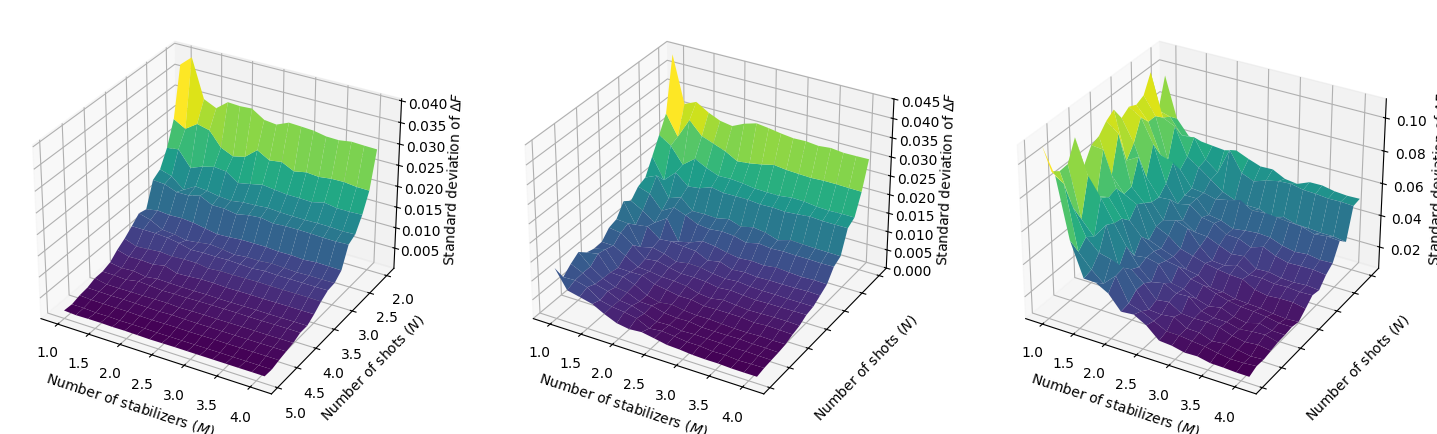

In [6]:
# This is again just a draft; the actual plot for the report is done in LaTeX
fig, axes = plt.subplots(
    1,
    len(err_models),
    figsize=(6 * len(err_models), 8),
    subplot_kw=dict(projection="3d"),
    sharey=True,
    sharex=True,
)

for i, err_model in enumerate(err_models):
    df_filtered = df_reduced[df_reduced["error_model"] == err_model]
    stds = df_filtered.groupby(["shots", "numstab"])["fidelity_error"].std()
    stds.index = stds.index.map(lambda x: (x[0] * 2, x[1]))

    idx = pd.IndexSlice
    stds = stds.loc[idx[::stride, ::stride]]

    axes[i].plot_surface(
        np.log10(numstabs_grid),
        np.log10(shots_grid),
        stds.unstack(level=-1),
        cmap=cm.viridis,
        linewidth=1,
        antialiased=True,
    )

    stds.to_csv(f"simulation_data/processed_csv/random_sampling_{err_model}.csv", sep="\t")

    axes[i].set_xlabel(r"Number of stabilizers ($M$)")
    axes[i].set_ylabel(r"Number of shots ($N$)")
    axes[i].yaxis.set_inverted(True)
    axes[i].set_zlabel(r"Standard deviation of $\Delta F$")

plt.show()